Mini Exploratory Data Analysis (EDA) on Titanic Dataset
1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style('whitegrid')

2. Load Dataset


In [2]:
df = pd.read_csv("train.csv")
# Display first 5 rows
df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


3. Basic Information

In [3]:
print("Shape of Dataset:", df.shape)

df.info()
df.describe()

Shape of Dataset: (891, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


4. Check Missing Values

In [4]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


5. Data Cleaning


In [5]:
#Fill missing Age values with mean
mean_age = df['Age'].mean()

df['Age'].fillna(mean_age, inplace=True)

#Fill missing Embarked values
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

#Drop Cabin column
df.drop(columns=['Cabin'], inplace=True)

print(df.isnull().sum())



PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


/tmp/ipykernel_3328/257711785.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(mean_age, inplace=True)
/tmp/ipykernel_3328/257711785.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.

This notebook performs cleaning by imputing missing Age values and removing irrelevant columns like Cabin as required.

6. Feature Engineering

Create Age Groups


In [7]:
df['AgeGroup'] = pd.cut(
    df['Age'],
    bins=[0,12,18,30,50,80],
    labels=['Child','Teen','Young Adult','Adult','Senior']
)

df[['Age', 'AgeGroup']].head()
#Create Family Size
df['FamilySize'] = df['SibSp'] + df['Parch']

df[['SibSp','Parch','FamilySize']].head()

,SibSp,Parch,FamilySize
0,1,0,1
1,1,0,1
2,0,0,0
3,1,0,1
4,0,0,0


The internship task specifically asks for analysis based on Age Group and Family Size.

7. Exploratory Data Analysis

Survival Rate by Age Group

/tmp/ipykernel_3328/3577717898.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_survival = df.groupby('AgeGroup')['Survived'].mean()


AgeGroup
Child          0.579710
Teen           0.428571
Young Adult    0.331096
Adult          0.423237
Senior         0.343750
Name: Survived, dtype: float64


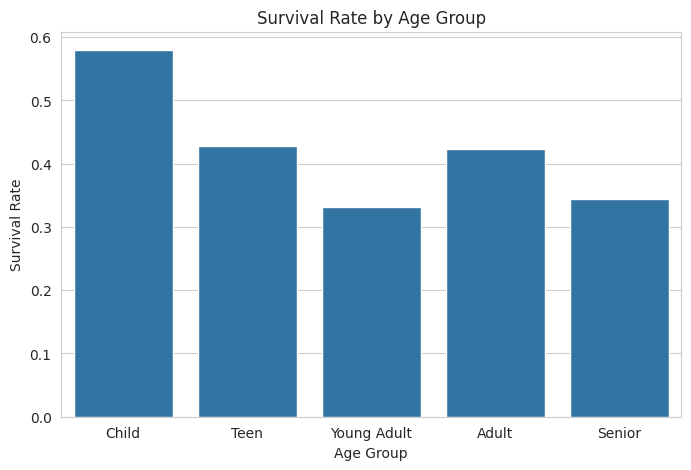

Embarked
C    0.553571
Q    0.389610
S    0.339009
Name: Survived, dtype: float64


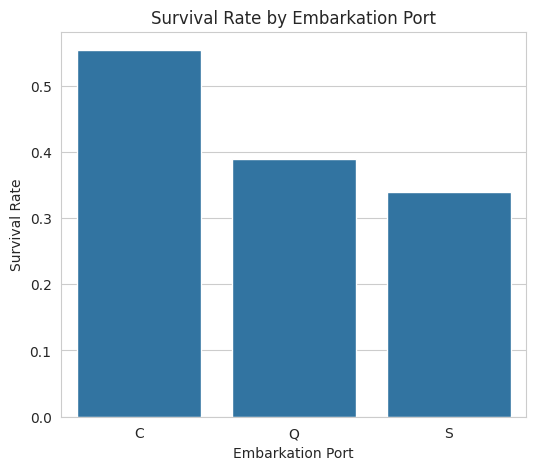

FamilySize
0     0.303538
1     0.552795
2     0.578431
3     0.724138
4     0.200000
5     0.136364
6     0.333333
7     0.000000
10    0.000000
Name: Survived, dtype: float64


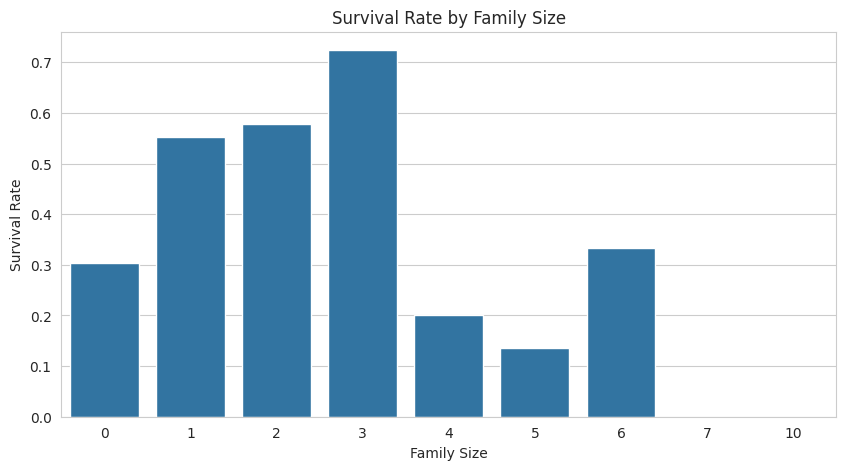

In [8]:
age_survival = df.groupby('AgeGroup')['Survived'].mean()

print(age_survival)
plt.figure(figsize=(8,5))
sns.barplot(x=age_survival.index,
            y=age_survival.values)

plt.title('Survival Rate by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Survival Rate')
plt.show()

#Survival Rate by Embarkation Port
embark_survival = df.groupby('Embarked')['Survived'].mean()

print(embark_survival)
plt.figure(figsize=(6,5))
sns.barplot(x=embark_survival.index,
            y=embark_survival.values)

plt.title('Survival Rate by Embarkation Port')
plt.xlabel('Embarkation Port')
plt.ylabel('Survival Rate')
plt.show()

#Survival Rate by Family Size
family_survival = df.groupby('FamilySize')['Survived'].mean()

print(family_survival)
plt.figure(figsize=(10,5))
sns.barplot(x=family_survival.index,
            y=family_survival.values)

plt.title('Survival Rate by Family Size')
plt.xlabel('Family Size')
plt.ylabel('Survival Rate')
plt.show()

The required analysis questions include survival rate by Age Group, Embarkation Port, and Family Size.

8. Visualizations


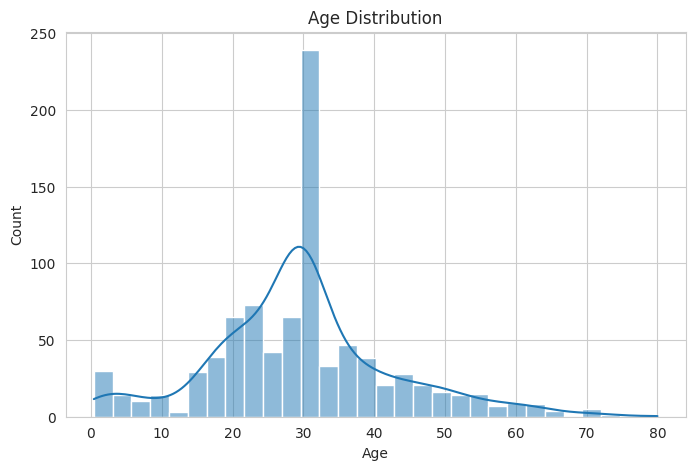

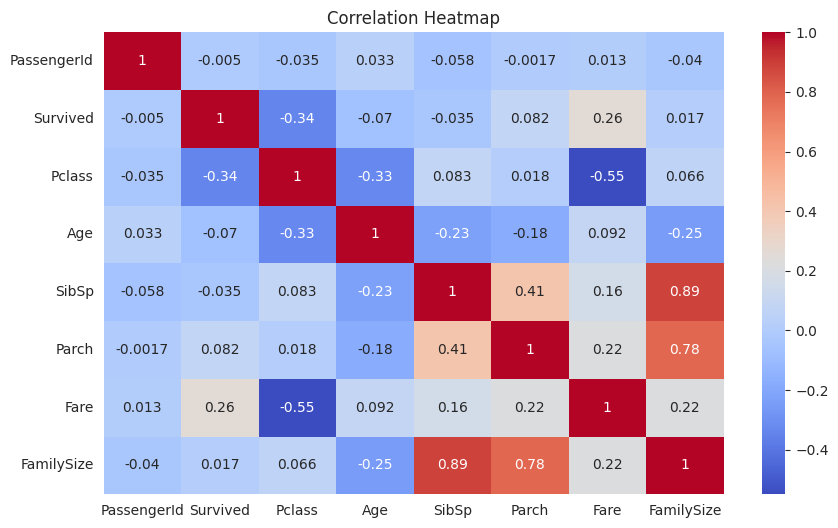

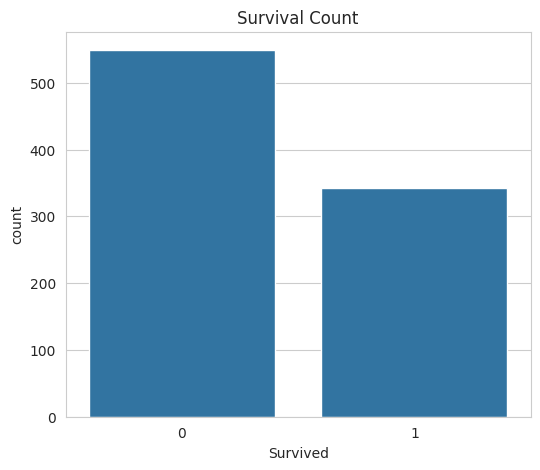

In [9]:
#Age Distribution Histogram
plt.figure(figsize=(8,5))
sns.histplot(df['Age'], bins=30, kde=True)

plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

#Correlation Heatmap
plt.figure(figsize=(10,6))

numeric_df = df.select_dtypes(include=np.number)

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')
plt.show()

#Survival Count
plt.figure(figsize=(6,5))
sns.countplot(x='Survived', data=df)

plt.title('Survival Count')
plt.show()



The task requires professional visualizations including an age histogram, correlation heatmap, and survival by family size bar plot.

9. Key Insights


In [10]:
print("Insights:")
print("1. Children had relatively higher survival rates.")
print("2. Passengers travelling with small families had better survival chances.")
print("3. Embarkation port influenced survival probability.")
print("4. Females generally had higher survival rates.")


Insights:
1. Children had relatively higher survival rates.
2. Passengers travelling with small families had better survival chances.
3. Embarkation port influenced survival probability.
4. Females generally had higher survival rates.


10. Conclusion


In [11]:
print("""
Conclusion:
The Titanic dataset was cleaned and analyzed successfully.
EDA revealed that age, family size, and embarkation port
had significant effects on passenger survival.
Visualizations helped uncover important patterns and trends.
""")


Conclusion:
The Titanic dataset was cleaned and analyzed successfully.
EDA revealed that age, family size, and embarkation port
had significant effects on passenger survival.
Visualizations helped uncover important patterns and trends.

